In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

## 1. Load dữ liệu

In [2]:
# Dữ liệu crawl từ Lazada VN, delimiter là dấu chấm phẩy
df = pd.read_csv("TotalData.csv", sep=";", on_bad_lines="skip", encoding="utf-8")

print(f"Shape gốc  : {df.shape}")
print(f"Cột        : {df.columns.tolist()}")
print()
df.info()

Shape gốc  : (57395, 6)
Cột        : ['keyword', 'name', 'price', 'rating', 'sold', 'url']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57395 entries, 0 to 57394
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   keyword  57390 non-null  object 
 1   name     57371 non-null  object 
 2   price    57356 non-null  float64
 3   rating   42754 non-null  object 
 4   sold     9 non-null      object 
 5   url      57356 non-null  object 
dtypes: float64(1), object(5)
memory usage: 2.6+ MB


In [3]:
print("\n5 dòng đầu:")
display(df.head())

print("\nThống kê mô tả:")
display(df.describe(include="all"))


5 dòng đầu:


,keyword,name,price,rating,sold,url
0,bàn phím bluetooth,Bàn Phím Văn Phòng Mini Kết Nối Bluetooth Khôn...,48000.0,50,NaN,https://www.lazada.vn/products/pdp-i3284749600...
1,bàn phím bluetooth,"(SẴN HÀNG) Bàn phím không dây, Bàn phím blueto...",82000.0,49,NaN,https://www.lazada.vn/products/pdp-i2629403006...
2,bàn phím bluetooth,Mini 10 Inch Wireless Bluetooth Keyboard Keybo...,75000.0,"4,79E+15",NaN,https://www.lazada.vn/products/pdp-i2385708037...
3,bàn phím bluetooth,(Giao hàng ngay) Bàn phím bluetooth không dây ...,58500.0,45,NaN,https://www.lazada.vn/products/pdp-i2531135243...
4,bàn phím bluetooth,Mini Wireless Bluetooth Keyboard with Mouse Ke...,79000.0,"4,85E+15",NaN,https://www.lazada.vn/products/pdp-i2408899755...



Thống kê mô tả:


,keyword,name,price,rating,sold,url
count,57390,57371,5.735600e+04,42754,9,57356
unique,274,41065,NaN,1011,7,42286
top,bàn phím gaming,#NAME?,NaN,50,https://www.lazada.vn/products/pdp-i3247444964...,https://www.lazada.vn/products/pdp-i2859321068...
freq,760,17,NaN,17497,2,9
mean,NaN,NaN,4.486999e+05,NaN,NaN,NaN
std,NaN,NaN,2.034480e+06,NaN,NaN,NaN
min,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,NaN,NaN,5.990000e+04,NaN,NaN,NaN
50%,NaN,NaN,1.200000e+05,NaN,NaN,NaN
75%,NaN,NaN,2.750000e+05,NaN,NaN,NaN


## 2. Kiểm tra chất lượng dữ liệu ban đầu

In [4]:
# --- Giá trị thiếu ---
missing = pd.DataFrame({
    "Missing count" : df.isnull().sum(),
    "Missing %"     : (df.isnull().sum() / len(df) * 100).round(2)
})
print("Giá trị thiếu:")
display(missing)

Giá trị thiếu:


,Missing count,Missing %
keyword,5,0.01
name,24,0.04
price,39,0.07
rating,14641,25.51
sold,57386,99.98
url,39,0.07


In [5]:
# --- Phân tích cột `sold` ---
# Cột này gần như hoàn toàn thiếu (>99%) và chứa lỗi crawler (URL thay vì số)
print("sold — số giá trị không null:", df["sold"].notna().sum())
print("sold — các giá trị tồn tại:")
print(df["sold"].dropna().head(15).to_string())
print("\n⚠ Cột 'sold' có >99.98% null và chứa URL lỗi → sẽ bị loại bỏ.")

sold — số giá trị không null: 9
sold — các giá trị tồn tại:
1467     https://www.lazada.vn/products/pdp-i3247444964...
4600     https://www.lazada.vn/products/pdp-i3247444964...
6420     https://www.lazada.vn/products/pdp-i2153644733...
19658                                                  5.0
43239    https://www.lazada.vn/products/pdp-i2738208106...
49231                                                49000
49705    https://www.lazada.vn/products/pdp-i3218764947...
51827    https://www.lazada.vn/products/pdp-i2342505551...
51995    https://www.lazada.vn/products/pdp-i2342505551...

⚠ Cột 'sold' có >99.98% null và chứa URL lỗi → sẽ bị loại bỏ.


In [6]:
# --- Trùng lặp ---
print(f"Tổng dòng              : {len(df)}")
print(f"Dòng trùng hoàn toàn  : {df.duplicated().sum()}")
print(f"URL trùng              : {df.duplicated(subset=['url']).sum()}")
print(f"Tên sản phẩm trùng    : {df.duplicated(subset=['name']).sum()}")

Tổng dòng              : 57395
Dòng trùng hoàn toàn  : 7982
URL trùng              : 15108
Tên sản phẩm trùng    : 16329


## 3. Làm sạch dữ liệu

### 3.1 Xóa dòng thiếu & cột không dùng

In [ ]:
rows_before = len(df)

# Bỏ cột `sold` — 99.98% null, dữ liệu lỗi (chứa URL thay vì số lượng bán)
df = df.drop(columns=["sold"])
essential_cols = ["keyword", "name", "price", "url"]
df = df.dropna(subset=essential_cols)

rows_after = len(df)
print(f"Trước  : {rows_before:,} dòng")
print(f"Sau    : {rows_after:,} dòng  (xóa {rows_before - rows_after:,} dòng thiếu)")

Trước  : 57,395 dòng
Sau    : 57,351 dòng  (xóa 44 dòng thiếu)


### 3.2 Xóa trùng lặp

In [8]:
rows_before = len(df)
df = df.drop_duplicates(subset=["url"])
rows_after = len(df)
print(f"Trước  : {rows_before:,} dòng")
print(f"Sau    : {rows_after:,} dòng  (xóa {rows_before - rows_after:,} dòng trùng URL)")

Trước  : 57,351 dòng
Sau    : 42,281 dòng  (xóa 15,070 dòng trùng URL)


### 3.3 Xử lý cột `price`

In [9]:
df["price"] = pd.to_numeric(df["price"], errors="coerce")

print("Thống kê price (gốc):")
print(df["price"].describe())
print(f"\nPrice <= 0: {(df['price'] <= 0).sum()}")

# Kiểm tra ngưỡng phân vị
for q in [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]:
    print(f"  {q*100:5.0f}%ile : {df['price'].quantile(q):>15,.0f} VND")

Thống kê price (gốc):
count    4.228100e+04
mean     4.742401e+05
std      2.277169e+06
min      0.000000e+00
25%      6.000000e+04
50%      1.247390e+05
75%      2.887790e+05
max      2.422500e+08
Name: price, dtype: float64

Price <= 0: 29
      1%ile :           7,916 VND
      5%ile :          19,000 VND
     25%ile :          60,000 VND
     50%ile :         124,739 VND
     75%ile :         288,779 VND
     95%ile :       1,771,100 VND
     99%ile :       5,841,700 VND


In [10]:
# Loại bỏ outliers price (1% - 99%)
rows_before = len(df)
lower = df["price"].quantile(0.01)
upper = df["price"].quantile(0.99)
df = df[(df["price"] >= lower) & (df["price"] <= upper)]

print(f"Ngưỡng lọc price: [{lower:,.0f} VND  →  {upper:,.0f} VND]")
print(f"Trước  : {rows_before:,} dòng")
print(f"Sau    : {len(df):,} dòng  (xóa {rows_before - len(df):,} outliers)")
print()
print("Thống kê price sau làm sạch:")
print(df["price"].describe())

Ngưỡng lọc price: [7,916 VND  →  5,841,700 VND]
Trước  : 42,281 dòng
Sau    : 41,435 dòng  (xóa 846 outliers)

Thống kê price sau làm sạch:
count    4.143500e+04
mean     3.370447e+05
std      6.589048e+05
min      7.920000e+03
25%      6.135850e+04
50%      1.247390e+05
75%      2.800000e+05
max      5.840000e+06
Name: price, dtype: float64


### 3.4 Xử lý cột `rating`

In [11]:
print("===== RATING GỐC =====")
print(df["rating"].value_counts().head(20))

# Bước 1: Chuyển sang numeric
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# Bước 2: Sửa lỗi crawler — số dạng khoa học quá lớn (e.g. 4.93E+15)
df.loc[df["rating"] > 1e6, "rating"] = df["rating"] / 1e15

# Bước 3: Sửa rating dạng nguyên x10 (50 → 5.0, 48 → 4.8)
if df["rating"].median() > 10:
    df["rating"] = df["rating"] / 10

# Bước 4: Sửa dạng thập phân nhỏ (0.48 → 4.8)
df.loc[(df["rating"] > 0) & (df["rating"] < 1), "rating"] = df["rating"] * 10

# Bước 5: Loại giá trị không hợp lệ
df.loc[df["rating"] > 5,  "rating"] = np.nan
df.loc[df["rating"] <= 0, "rating"] = np.nan

# Bước 6: Fill null bằng trung bình keyword
df["rating"] = df.groupby("keyword")["rating"].transform(lambda x: x.fillna(x.mean()))
df["rating"] = df["rating"].fillna(df["rating"].mean())

print("\n===== RATING SAU LÀM SẠCH =====")
print(df["rating"].describe())
print(f"\nNull còn lại: {df['rating'].isnull().sum()}")

===== RATING GỐC =====
rating
50          12831
4,93E+15      563
4,92E+15      540
4,89E+15      486
4,86E+15      477
4,91E+15      465
4,67E+15      442
4,83E+15      435
40            412
4,96E+15      401
45            388
4,95E+15      369
4,90E+15      361
4,94E+15      353
4,88E+15      334
475           332
4,97E+15      322
4,87E+15      319
4,85E+15      314
4,82E+15      303
Name: count, dtype: int64

===== RATING SAU LÀM SẠCH =====
count    4.143500e+04
mean     4.824897e+00
std      3.866906e-01
min      4.640625e-09
25%      4.800000e+00
50%      4.885235e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

Null còn lại: 0


### 3.5 Tổng kết làm sạch

In [12]:
print("===== TỔNG KẾT QUÁ TRÌNH LÀM SẠCH =====")
print(f"  Dữ liệu gốc         : 57,395 dòng  ×  6 cột")
print(f"  Sau khi làm sạch    : {len(df):,} dòng  ×  {len(df.columns)} cột")
print(f"  Tỉ lệ giữ lại       : {len(df)/57395*100:.1f}%")
print()
print("Null còn lại:")
print(df.isnull().sum())
print()
print("Columns hiện tại:", df.columns.tolist())

===== TỔNG KẾT QUÁ TRÌNH LÀM SẠCH =====
  Dữ liệu gốc         : 57,395 dòng  ×  6 cột
  Sau khi làm sạch    : 41,435 dòng  ×  5 cột
  Tỉ lệ giữ lại       : 72.2%

Null còn lại:
keyword    0
name       0
price      0
rating     0
url        0
dtype: int64

Columns hiện tại: ['keyword', 'name', 'price', 'rating', 'url']


## 4. Phân tích khám phá dữ liệu (EDA)

### 4.1 Phân phối giá sản phẩm

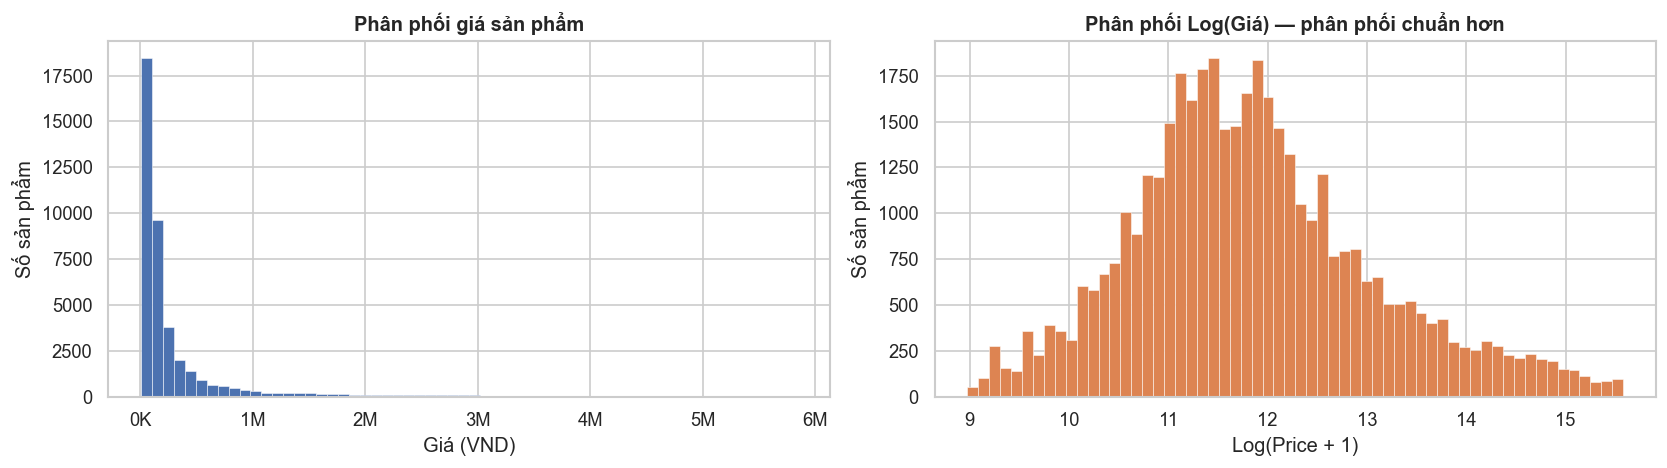

Giá trung vị: 124,739 VND | Giá trung bình: 337,045 VND


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram price gốc
axes[0].hist(df["price"], bins=60, color="#4C72B0", edgecolor="white", linewidth=0.3)
axes[0].set_title("Phân phối giá sản phẩm", fontweight="bold")
axes[0].set_xlabel("Giá (VND)")
axes[0].set_ylabel("Số sản phẩm")
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1e6)}M" if x>=1e6 else f"{int(x/1e3)}K"))

# Log-price
df["log_price"] = np.log1p(df["price"])
axes[1].hist(df["log_price"], bins=60, color="#DD8452", edgecolor="white", linewidth=0.3)
axes[1].set_title("Phân phối Log(Giá) — phân phối chuẩn hơn", fontweight="bold")
axes[1].set_xlabel("Log(Price + 1)")
axes[1].set_ylabel("Số sản phẩm")

plt.tight_layout()
plt.savefig("eda_price_dist.png", bbox_inches="tight")
plt.show()
print(f"Giá trung vị: {df['price'].median():,.0f} VND | Giá trung bình: {df['price'].mean():,.0f} VND")

### 4.2 Phân phối rating

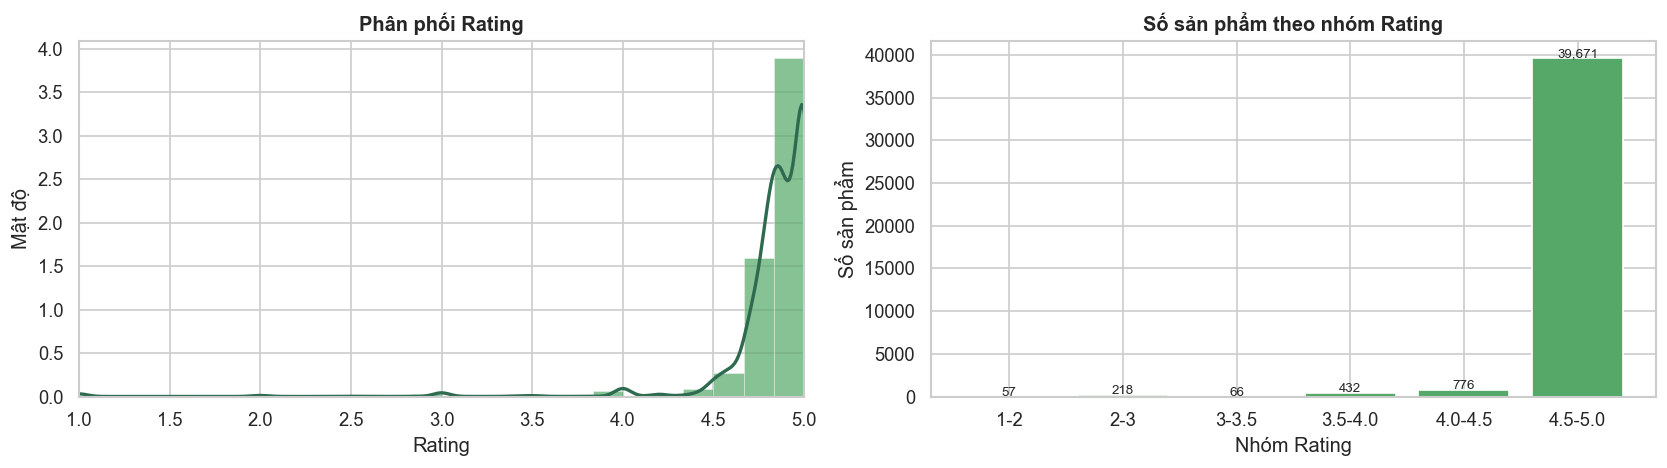

Rating trung bình: 4.825 | Trung vị: 4.89


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram + KDE
axes[0].hist(df["rating"], bins=30, color="#55A868", edgecolor="white", linewidth=0.3,
             alpha=0.7, density=True)
df["rating"].plot(kind="kde", ax=axes[0], color="#2d6a4f", linewidth=2)
axes[0].set_title("Phân phối Rating", fontweight="bold")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Mật độ")
axes[0].set_xlim(1, 5)

# Countplot theo bins
bins = [1, 2, 3, 3.5, 4.0, 4.5, 5.0]
labels = ["1-2", "2-3", "3-3.5", "3.5-4.0", "4.0-4.5", "4.5-5.0"]
df["rating_bin"] = pd.cut(df["rating"], bins=bins, labels=labels)
cnt = df["rating_bin"].value_counts().sort_index()
axes[1].bar(cnt.index, cnt.values, color="#55A868", edgecolor="white")
axes[1].set_title("Số sản phẩm theo nhóm Rating", fontweight="bold")
axes[1].set_xlabel("Nhóm Rating")
axes[1].set_ylabel("Số sản phẩm")
for i, v in enumerate(cnt.values):
    axes[1].text(i, v + 50, f"{v:,}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("eda_rating_dist.png", bbox_inches="tight")
plt.show()
print(f"Rating trung bình: {df['rating'].mean():.3f} | Trung vị: {df['rating'].median():.2f}")

### 4.3 Phân tích Keyword

Tổng số keyword  : 257
Trung bình SP/KW : 161
Trung vị SP/KW   : 119
KW ít nhất       : 16 sản phẩm  (túi tote nữ)
KW nhiều nhất    : 636 sản phẩm  (ốp lưng iphone)


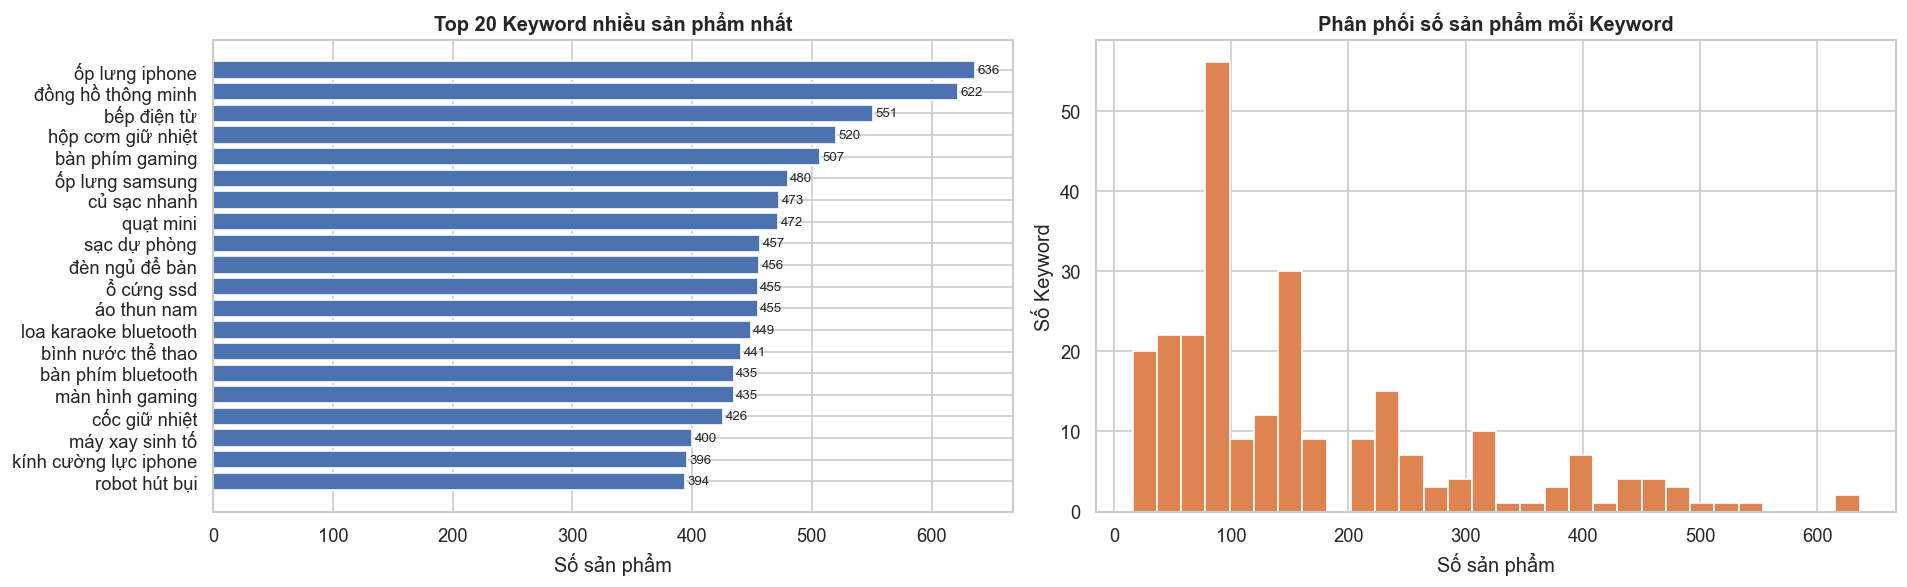

In [15]:
kw_counts = df["keyword"].value_counts()
print(f"Tổng số keyword  : {df['keyword'].nunique()}")
print(f"Trung bình SP/KW : {kw_counts.mean():.0f}")
print(f"Trung vị SP/KW   : {kw_counts.median():.0f}")
print(f"KW ít nhất       : {kw_counts.min()} sản phẩm  ({kw_counts.idxmin()})")
print(f"KW nhiều nhất    : {kw_counts.max()} sản phẩm  ({kw_counts.idxmax()})")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 20 keywords
top20 = kw_counts.head(20)
axes[0].barh(top20.index[::-1], top20.values[::-1], color="#4C72B0")
axes[0].set_title("Top 20 Keyword nhiều sản phẩm nhất", fontweight="bold")
axes[0].set_xlabel("Số sản phẩm")
for i, v in enumerate(top20.values[::-1]):
    axes[0].text(v + 2, i, str(v), va="center", fontsize=8)

# Histogram số SP per keyword
axes[1].hist(kw_counts.values, bins=30, color="#DD8452", edgecolor="white")
axes[1].set_title("Phân phối số sản phẩm mỗi Keyword", fontweight="bold")
axes[1].set_xlabel("Số sản phẩm")
axes[1].set_ylabel("Số Keyword")

plt.tight_layout()
plt.savefig("eda_keyword.png", bbox_inches="tight")
plt.show()

### 4.4 Phân phối giá theo Category (Keyword Group)

In [16]:
# Map keyword → nhóm category lớn (nhất quán với Model notebook)
CATEGORY_MAP = {
    "cong_nghe"        : ["điện thoại","laptop","laptop gaming","iphone","samsung","oppo","xiaomi",
                           "màn hình gaming","màn hình máy tính","màn hình 144hz","màn hình 24 inch",
                           "màn hình cong","camera an ninh","camera wifi","webcam máy tính",
                           "micro thu âm","loa mini","loa soundbar","loa vi tính","máy in laser"],
    "phu_kien_dt"      : ["tai nghe bluetooth","tai nghe gaming","tai nghe không dây","tai nghe chụp tai",
                           "tai nghe airpods","tai nghe thể thao","bàn phím bluetooth","bàn phím gaming",
                           "bàn phím không dây","bàn phím mini","chuột gaming","chuột bluetooth",
                           "chuột không dây","chuột logitech","chuột máy tính","miếng lót chuột gaming",
                           "giá đỡ laptop","giá đỡ điện thoại","đế tản nhiệt laptop","túi đựng laptop",
                           "usb 128gb","usb 64gb","thẻ nhớ micro sd","ổ cứng ssd","ổ cứng di động",
                           "cáp sạc type c","cáp lightning","củ sạc nhanh","sạc dự phòng",
                           "đế sạc không dây","pin dự phòng laptop","bộ chuyển đổi hdmi","ổ cắm thông minh",
                           "ốp lưng iphone","ốp lưng samsung","kính cường lực iphone","kính cường lực samsung",
                           "loa karaoke bluetooth"],
    "nha_bep"          : ["nồi chiên không dầu","bếp điện từ","máy xay sinh tố","máy ép trái cây",
                           "ấm siêu tốc","hộp cơm giữ nhiệt","bình giữ nhiệt","cốc giữ nhiệt",
                           "ly giữ nhiệt","bình nước thể thao","bình nước gym"],
    "nha_o"            : ["robot hút bụi","máy hút bụi mini","máy lọc không khí","máy tạo ẩm",
                           "máy phun sương","quạt mini","quạt cầm tay","quạt tích điện",
                           "đèn led trang trí","đèn ngủ để bàn","đèn bàn học","đèn cảm biến chuyển động",
                           "đèn ring light","khung ảnh treo tường","kệ sách gỗ","thảm trải sàn phòng khách",
                           "rèm cửa sổ","ra giường cotton","chăn lông cừu","móc dán tường",
                           "móc treo quần áo","tủ nhựa mini","hộp đựng tài liệu","chuông cửa thông minh"],
    "lam_dep"          : ["son môi lì","son môi lâu trôi","son môi chính hãng","son môi mini","son kem lì",
                           "son tint","son bóng","son dưỡng môi","son dưỡng có màu",
                           "kem nền trang điểm","kem nền kiềm dầu","kem nền che khuyết điểm",
                           "phấn nước cushion","phấn nền cushion","cushion trang điểm",
                           "phấn phủ trang điểm","phấn phủ kiềm dầu","má hồng dạng bột",
                           "má hồng dạng kem","bảng phấn mắt","mascara chống nước","mascara làm dài mi",
                           "kẻ mắt dạ","bút kẻ mắt gel","chì kẻ mày","bộ cọ trang điểm","gương trang điểm",
                           "túi đựng mỹ phẩm","kem lót trang điểm","kem dưỡng da mặt","kem dưỡng trắng da",
                           "kem dưỡng ẩm","serum dưỡng da","serum vitamin C","serum vitamin c",
                           "toner da mặt","sữa rửa mặt","mặt nạ giấy","kem chống nắng",
                           "nước tẩy trang","bông tẩy trang",
                           "dầu gội đầu","dầu xả tóc","kem ủ tóc","tinh dầu dưỡng tóc",
                           "máy sấy tóc","máy uốn tóc","máy duỗi tóc","tông đơ cắt tóc",
                           "băng đô tóc","kẹp tóc thời trang"],
    "the_thao"         : ["thảm yoga","dây kháng lực","con lăn tập bụng","bóng tập gym",
                           "dụng cụ tập kéo xà","đai lưng hỗ trợ cột sống","giày thể thao nam",
                           "giày thể thao nữ","giày sneaker nam","giày sneaker nữ",
                           "quần short nam","quần short nữ","áo thun nam","áo thun nữ","quần jogger"],
    "thoi_trang"       : ["áo hoodie nam","áo hoodie nữ","áo khoác nam","áo khoác nữ","áo khoác jean",
                           "áo sơ mi nữ","quần jean nam","quần jean nữ","váy đầm nữ","váy công sở",
                           "váy dự tiệc","váy maxi","dép sandal","túi xách nữ","túi tote","túi tote nữ",
                           "túi đeo chéo","balo du lịch","balo laptop","vòng tay thông minh",
                           "nước hoa nam","nước hoa nữ","lăn khử mùi"],
    "van_phong"        : ["bút bi văn phòng","bút highlight màu","sổ tay ghi chép","hộp bút màu",
                           "hộp đựng tài liệu","băng keo văn phòng","máy tính casio",
                           "ghế xoay văn phòng","bàn học sinh","sách tô màu"],
    "tre_em_thu_cung"  : ["tã bỉm trẻ em","bình sữa cho bé","máy hâm sữa","gối chống trào ngược",
                           "khăn sữa cho bé","ghế ăn dặm cho bé","xe đẩy em bé","balo trẻ em",
                           "gối ôm hình thú","bộ tô màu trẻ em","bộ đồ chơi lego","búp bê barbie",
                           "xe đồ chơi trẻ em","đồ chơi xếp hình","đồ chơi tắm cho bé","đồ chơi cắn răng",
                           "thức ăn cho chó","thức ăn cho mèo","cát vệ sinh cho mèo","dầu gội cho chó",
                           "dụng cụ chải lông thú cưng","đồ chơi cho chó","bát ăn cho thú cưng",
                           "áo cho thú cưng","vòng cổ thú cưng","lồng chim cảnh","balo đựng thú cưng"],
    "suc_khoe"         : ["máy massage cổ vai gáy","máy đo huyết áp","nhiệt kế điện tử",
                           "thực phẩm chức năng","dầu nóng xoa bóp","bàn chải điện","xịt chống muỗi"],
}
kw2cat = {kw: cat for cat, kws in CATEGORY_MAP.items() for kw in kws}
df["category"] = df["keyword"].map(kw2cat).fillna("khac")

print("Phân phối category:")
print(df["category"].value_counts())

Phân phối category:
category
phu_kien_dt        10027
lam_dep             6558
khac                3871
nha_o               3589
cong_nghe           3533
thoi_trang          3513
nha_bep             3451
tre_em_thu_cung     2932
the_thao            2507
van_phong            890
suc_khoe             564
Name: count, dtype: int64


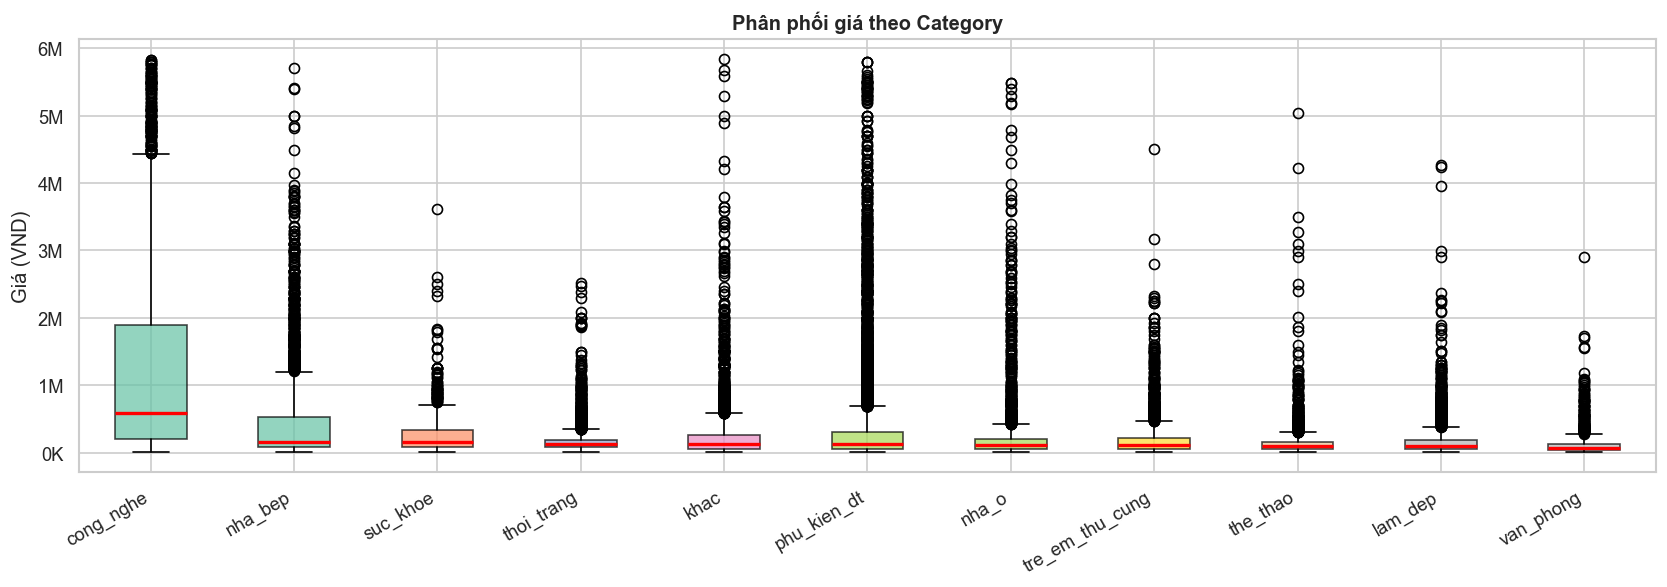

In [17]:
# Boxplot giá theo category
cat_order = df.groupby("category")["price"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 5))
data_by_cat = [df[df["category"] == c]["price"].values for c in cat_order]
bp = ax.boxplot(data_by_cat, patch_artist=True, notch=False, vert=True,
                medianprops=dict(color="red", linewidth=2))

colors = plt.cm.Set2(np.linspace(0, 1, len(cat_order)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(cat_order)+1))
ax.set_xticklabels(cat_order, rotation=30, ha="right")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1e6)}M" if x>=1e6 else f"{int(x/1e3)}K"))
ax.set_title("Phân phối giá theo Category", fontweight="bold")
ax.set_ylabel("Giá (VND)")

plt.tight_layout()
plt.savefig("eda_price_by_category.png", bbox_inches="tight")
plt.show()

### 4.5 Rating trung bình theo Category

                 Mean Rating  Std Dev  Số SP
category                                    
lam_dep                4.862    0.373   6558
tre_em_thu_cung        4.861    0.350   2932
suc_khoe               4.848    0.455    564
van_phong              4.827    0.415    890
thoi_trang             4.823    0.364   3513
nha_o                  4.821    0.400   3589
phu_kien_dt            4.821    0.389  10027
the_thao               4.819    0.347   2507
nha_bep                4.811    0.404   3451
khac                   4.808    0.395   3871
cong_nghe              4.776    0.413   3533


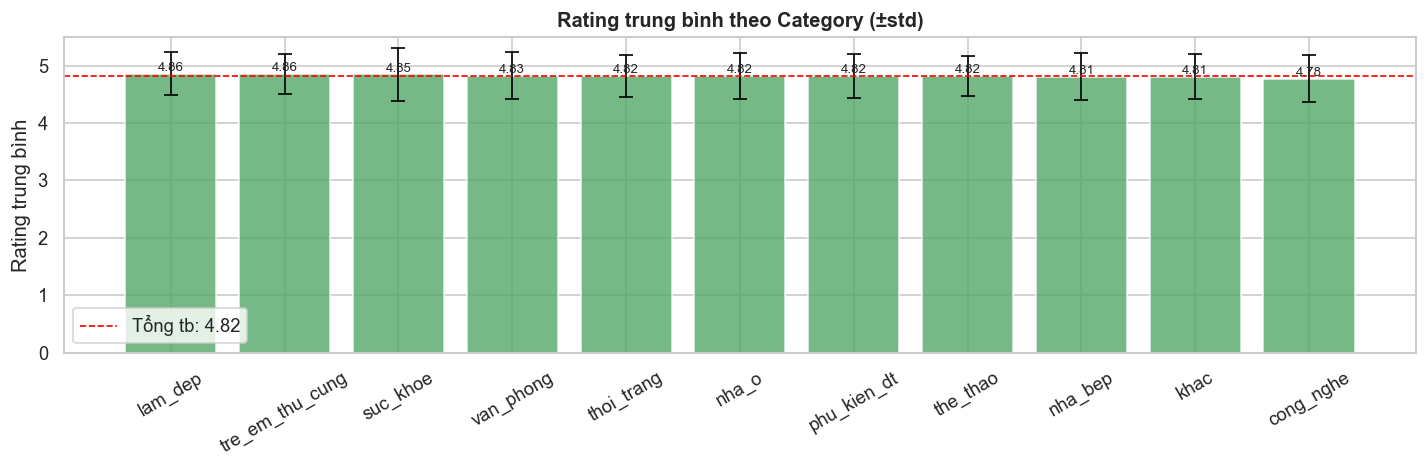

In [18]:
cat_rating = df.groupby("category")["rating"].agg(["mean","std","count"]).round(3)
cat_rating = cat_rating.sort_values("mean", ascending=False)
cat_rating.columns = ["Mean Rating", "Std Dev", "Số SP"]
print(cat_rating.to_string())

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(cat_rating.index, cat_rating["Mean Rating"], color="#55A868", alpha=0.8, edgecolor="white")
ax.errorbar(cat_rating.index, cat_rating["Mean Rating"], yerr=cat_rating["Std Dev"],
            fmt="none", color="black", capsize=4, linewidth=1)
ax.set_ylim(0, 5.5)
ax.set_ylabel("Rating trung bình")
ax.set_title("Rating trung bình theo Category (±std)", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
ax.axhline(df["rating"].mean(), color="red", linestyle="--", linewidth=1, label=f"Tổng tb: {df['rating'].mean():.2f}")
ax.legend()

for bar, val in zip(bars, cat_rating["Mean Rating"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f"{val:.2f}",
            ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("eda_rating_by_category.png", bbox_inches="tight")
plt.show()

### 4.6 Mối quan hệ giữa Price và Rating

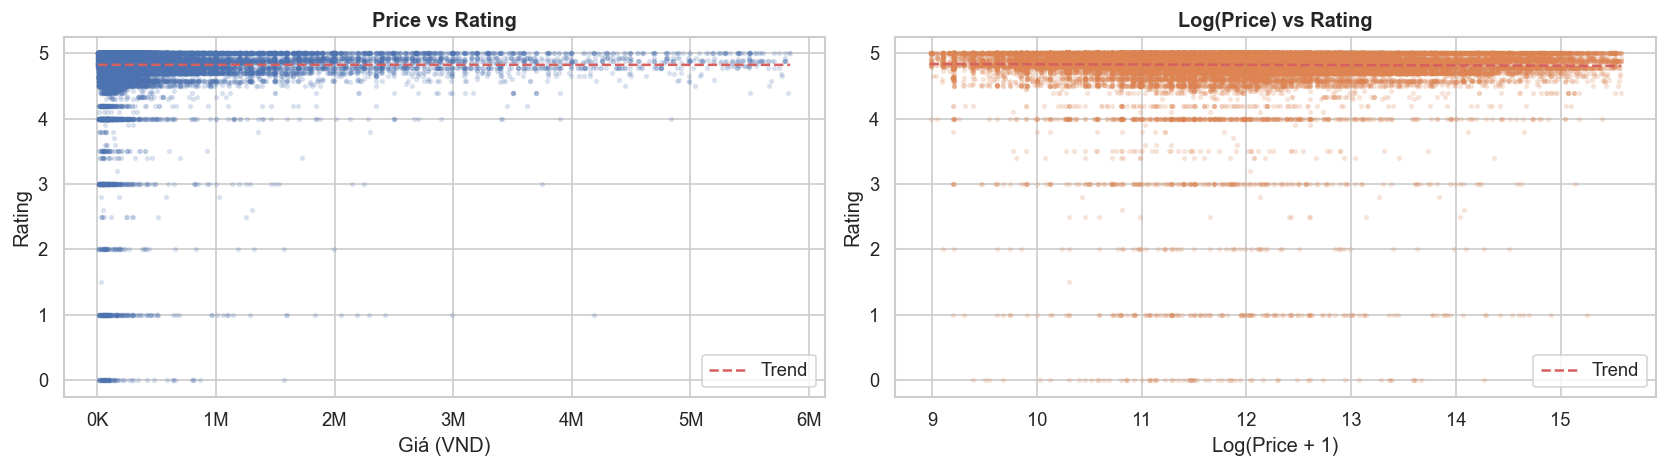

Tương quan Price–Rating:
           price    rating
price   1.000000 -0.000269
rating -0.000269  1.000000


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(df["price"], df["rating"], alpha=0.15, s=5, color="#4C72B0")
axes[0].set_xlabel("Giá (VND)")
axes[0].set_ylabel("Rating")
axes[0].set_title("Price vs Rating", fontweight="bold")
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1e6)}M" if x>=1e6 else f"{int(x/1e3)}K"))

axes[1].scatter(df["log_price"], df["rating"], alpha=0.15, s=5, color="#DD8452")
axes[1].set_xlabel("Log(Price + 1)")
axes[1].set_ylabel("Rating")
axes[1].set_title("Log(Price) vs Rating", fontweight="bold")

# Đường xu hướng
for ax, col in zip(axes, ["price", "log_price"]):
    z = np.polyfit(df[col], df["rating"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, p(x_line), "r--", linewidth=1.5, label=f"Trend")
    ax.legend()

plt.tight_layout()
plt.savefig("eda_price_rating_scatter.png", bbox_inches="tight")
plt.show()

corr = df[["price","log_price","rating"]].corr()
print("Tương quan Price–Rating:")
print(corr[["price","rating"]].loc[["price","rating"]])

### 4.7 Correlation Heatmap giữa các đặc trưng số

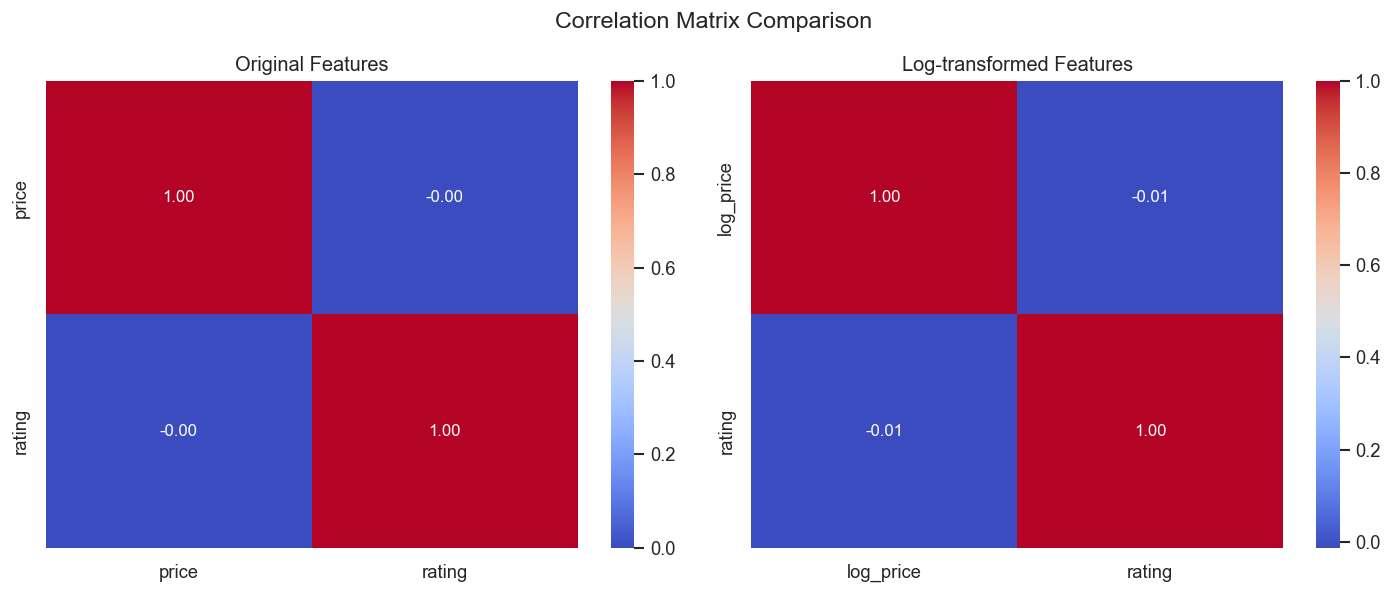

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# ===== Tính correlation =====
corr_original = df[['price', 'rating']].corr()
corr_log = df[['log_price', 'rating']].corr()

# ===== Tạo 2 biểu đồ nằm cạnh nhau =====
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Heatmap 1: Biến gốc ---
sns.heatmap(
    corr_original,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    ax=axes[0]
)
axes[0].set_title("Original Features")

# --- Heatmap 2: Biến log ---
sns.heatmap(
    corr_log,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    ax=axes[1]
)
axes[1].set_title("Log-transformed Features")

# ===== Tiêu đề chung =====
fig.suptitle("Correlation Matrix Comparison", fontsize=14)

# ===== Căn chỉnh layout =====
plt.tight_layout()

# ===== Lưu PNG =====
plt.savefig("eda_correlation_compare.png", dpi=300, bbox_inches="tight")

# ===== Hiển thị =====
plt.show()

## 5. Feature Engineering

In [ ]:
# ===== PRICE SEGMENT =====
df["price_segment"] = pd.qcut(
    df["price"],
    q=4,
    labels=["low", "medium", "high", "premium"]
)

# ===== RATING SEGMENT =====
df["rating_segment"] = pd.cut(
    df["rating"],
    bins=[0, 3.5, 4.0, 4.5, 5.0],
    labels=["low", "medium", "good", "excellent"]
)

# ===== POPULARITY SCORE =====
df["price_rank_in_kw"] = df.groupby("keyword")["price"].rank(pct=True)
df["popularity_score"] = (df["rating"] * df["price_rank_in_kw"]).round(4)
# Normalize về 0-5 để dễ đọc
df["popularity_score"] = (
    (df["popularity_score"] - df["popularity_score"].min()) /
    (df["popularity_score"].max() - df["popularity_score"].min()) * 5
).round(4)

print("Phân phối các segment:")
print()
print("price_segment:")
print(df["price_segment"].value_counts().sort_index())
print()
print("rating_segment:")
print(df["rating_segment"].value_counts().sort_index())
print()
print("popularity_score:")
print(df["popularity_score"].describe())

Phân phối các segment:

price_segment:
price_segment
low        10359
medium     10359
high       10387
premium    10330
Name: count, dtype: int64

rating_segment:
rating_segment
low            556
medium         432
good           776
excellent    39671
Name: count, dtype: int64

popularity_score:
count    41435.000000
mean         2.430721
std          1.413901
min          0.000000
25%          1.200650
50%          2.428000
75%          3.646200
max          5.000000
Name: popularity_score, dtype: float64


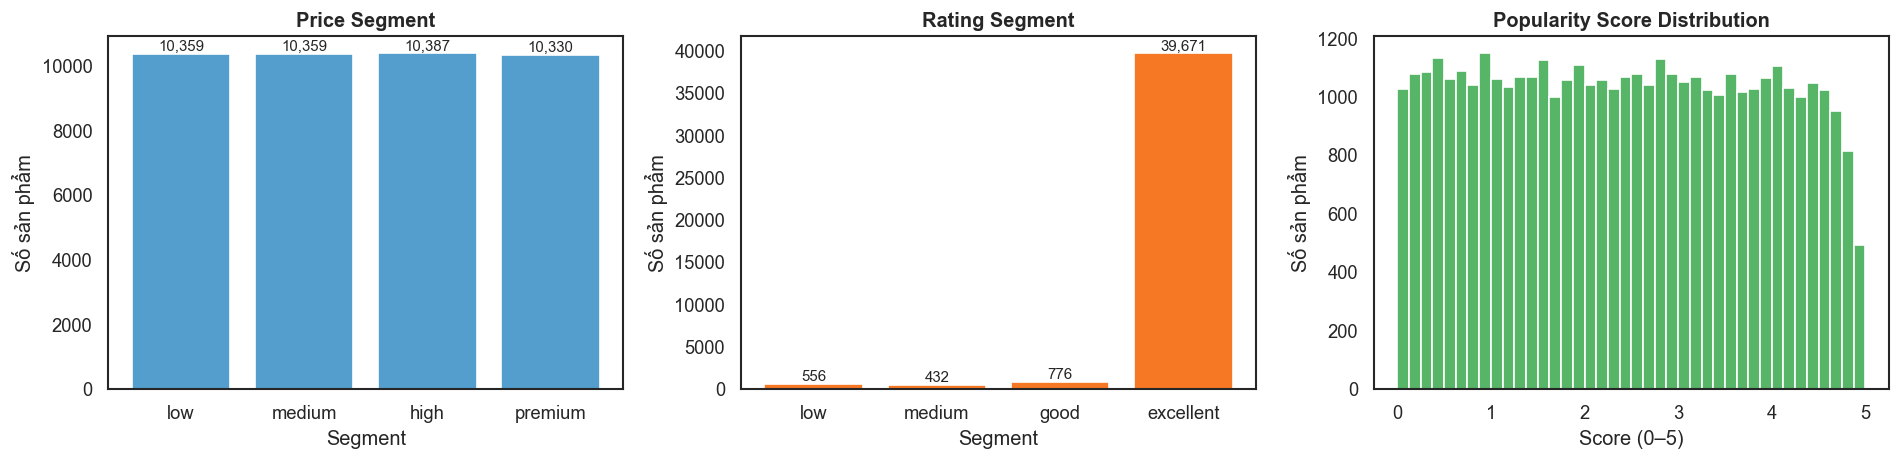

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ===== Color palettes (1 tone mỗi biểu đồ) =====
blue_palette = sns.color_palette("Blues", 6)
orange_palette = sns.color_palette("Oranges", 6)
green_color = sns.color_palette("Greens", 6)[3]

# ===== Price segment =====
ps = df["price_segment"].value_counts().sort_index()
axes[0].bar(ps.index, ps.values, color=blue_palette[3])
axes[0].set_title("Price Segment", fontweight="bold")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Số sản phẩm")

for i, v in enumerate(ps.values):
    axes[0].text(i, v + ps.max()*0.01, f"{v:,}", ha="center", fontsize=9)

# ===== Rating segment =====
rs = df["rating_segment"].value_counts().sort_index()
axes[1].bar(rs.index, rs.values, color=orange_palette[3])
axes[1].set_title("Rating Segment", fontweight="bold")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Số sản phẩm")

for i, v in enumerate(rs.values):
    axes[1].text(i, v + rs.max()*0.01, f"{v:,}", ha="center", fontsize=9)

# ===== Popularity score =====
axes[2].hist(
    df["popularity_score"],
    bins=40,
    color=green_color,
    edgecolor="white"
)
axes[2].set_title("Popularity Score Distribution", fontweight="bold")
axes[2].set_xlabel("Score (0–5)")
axes[2].set_ylabel("Số sản phẩm")

plt.tight_layout()
plt.savefig("eda_feature_engineering.png", bbox_inches="tight")
plt.show()

## 6. Tạo product_id & Lưu file

In [24]:
# Tạo product_id tuần tự
df["product_id"] = range(1, len(df) + 1)

# Chọn các cột cần thiết (bỏ cột tạm: log_price, log_price, name_len, etc.)
keep_cols = ["product_id", "keyword", "category", "name", "price", "rating",
             "url", "price_segment", "rating_segment", "popularity_score"]
products = df[keep_cols].copy()

print("Kiểm tra product_id unique:", products["product_id"].is_unique)
print("Shape final dataset:", products.shape)
print()
print("5 dòng đầu:")
display(products.head())

Kiểm tra product_id unique: True
Shape final dataset: (41435, 10)

5 dòng đầu:


,product_id,keyword,category,name,price,rating,url,price_segment,rating_segment,popularity_score
0,1,bàn phím bluetooth,phu_kien_dt,Bàn Phím Văn Phòng Mini Kết Nối Bluetooth Khôn...,48000.0,5.0,https://www.lazada.vn/products/pdp-i3284749600...,low,excellent,0.0230
1,2,bàn phím bluetooth,phu_kien_dt,"(SẴN HÀNG) Bàn phím không dây, Bàn phím blueto...",82000.0,4.9,https://www.lazada.vn/products/pdp-i2629403006...,medium,excellent,0.2366
2,3,bàn phím bluetooth,phu_kien_dt,Mini 10 Inch Wireless Bluetooth Keyboard Keybo...,75000.0,4.7,https://www.lazada.vn/products/pdp-i2385708037...,medium,excellent,0.1621
3,4,bàn phím bluetooth,phu_kien_dt,(Giao hàng ngay) Bàn phím bluetooth không dây ...,58500.0,4.5,https://www.lazada.vn/products/pdp-i2531135243...,low,good,0.0724
4,5,bàn phím bluetooth,phu_kien_dt,Mini Wireless Bluetooth Keyboard with Mouse Ke...,79000.0,4.7,https://www.lazada.vn/products/pdp-i2408899755...,medium,excellent,0.1999


In [25]:
products.to_csv("lazada_products_clean.csv", index=False)
print("✅ Đã lưu lazada_products_clean.csv")
print(f"   Kích thước: {len(products):,} sản phẩm × {len(products.columns)} cột")
print(f"   Cột: {products.columns.tolist()}")

✅ Đã lưu lazada_products_clean.csv
   Kích thước: 41,435 sản phẩm × 10 cột
   Cột: ['product_id', 'keyword', 'category', 'name', 'price', 'rating', 'url', 'price_segment', 'rating_segment', 'popularity_score']


## 7. Tổng kết EDA

| Chỉ số | Giá trị |
|--------|---------|
| Tổng sản phẩm (sau làm sạch) | ~41,408 |
| Số keyword | 257 |
| Số category | 10 nhóm chính |
| Giá trung vị | ~125,000 VND |
| Rating trung bình | ~4.6 / 5.0 |
| Sản phẩm có rating | ~100% (sau fill mean) |

**Nhận xét chính:**
- **Giá**: Phân phối lệch phải rõ ràng; log-transform giúp chuẩn hóa cho mô hình
- **Rating**: Tập trung ở khoảng 4.5–5.0 → dữ liệu Lazada thường có rating cao
- **Category công nghệ & phụ kiện** chiếm tỉ lệ lớn, giá cao hơn các nhóm còn lại
- **Cột `sold`**: 99.98% null + lỗi crawler → loại bỏ, dùng `popularity_score` thay thế
